In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import json


# 1. Carga de datos

In [2]:
# Cargamos los datos
df = pd.read_csv("dataset/datos_finales.csv") # Datos scrapeados

# Cargamos los datos relacionados con las tasas de empleo y paro
df_paro = pd.read_csv(
    "dataset/datos_paro_actividad_ine.csv",
    sep=";",
    encoding="cp1252"
) # https://www.ine.es/jaxiT3/Tabla.htm?t=65349

# Importamos los mapeos de provincias del INE para nuestro dataset original
with open("dataset/provincia_mapping.json", "r", encoding="utf-8") as f:
    prov_map = json.load(f)

# Cargamos los datos de rentas netas medias por persona y hogar por cada provincia
df_rentas = pd.read_csv(
    "dataset/datos_rentas_ine.csv",
    sep=";",
    encoding="cp1252"
) # https://www.ine.es/jaxiT3/files/t/csv_bdsc

# Cargamos los datos del turimos
df_turism = pd.read_csv(
    "dataset/datos_turismo_ine.csv",
    sep=";",
    encoding="utf-8"
)

df_empresas= pd.read_csv(
    "dataset/datos_num_empresas_ine.csv",
    sep=";",
    encoding="cp1252"
)


# 2. Data cleaning
## 2.1 Datos tasa de paro y actividad economica

In [3]:
df_paro

,Sexo,Provincias,Tasas,Periodo,Total
0,Ambos sexos,02 Albacete,Tasa de actividad,2023T4,"57,42"
1,Ambos sexos,02 Albacete,Tasa de actividad,2022T4,"58,46"
2,Ambos sexos,02 Albacete,Tasa de actividad,2021T4,"54,60"
3,Ambos sexos,02 Albacete,Tasa de actividad,2020T4,"58,90"
4,Ambos sexos,02 Albacete,Tasa de actividad,2019T4,"55,54"
...,...,...,...,...,...
1243,Ambos sexos,52 Melilla,Tasa de empleo de la población,2020T4,"49,93"
1244,Ambos sexos,52 Melilla,Tasa de empleo de la población,2019T4,"42,51"
1245,Ambos sexos,52 Melilla,Tasa de empleo de la población,2018T4,"47,23"
1246,Ambos sexos,52 Melilla,Tasa de empleo de la población,2017T4,"45,77"


In [4]:
# Nos quedamos con el periodo mas reciente y el datos de hombres y mujeres combinado
df_paro[(df_paro['Periodo'] =='2026T1') & (df_paro['Sexo']=='Ambos sexos')]

# Limpiamos el indice provincias de la numeracion del INE
df_paro["Provincia"] = df_paro["Provincias"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)   

df_paro["Año"] = df_paro["Periodo"].str[:4]

df_paro["Variable"] = (
    df_paro["Tasas"]
    .str.replace("Tasa de ", "", regex=False)
    .str.replace(" de la población", "", regex=False)
    .str.replace(" ", "_")
    + "_"
    + df_paro["Año"]
)

df_paro["Total"] = (
    df_paro["Total"]
    .astype(str)
    .str.replace(",", ".", regex=False)  # miles1.000
)
df_paro["Total"] = df_paro["Total"].astype(float)
    
df_paro_pivot = df_paro.pivot_table(
    index="Provincia",
    columns="Variable",
    values="Total",
    aggfunc="first"
).reset_index()

# Reemplazamos los nombres de las provincias del INE a las del df original
df_paro_pivot["Provincia"] = df_paro_pivot["Provincia"].replace(prov_map)

lst_pivo_col = df_paro_pivot.columns[1:]

df_paro_pivot.head(5)

Variable,Provincia,actividad_2016,actividad_2017,actividad_2018,actividad_2019,actividad_2020,actividad_2021,actividad_2022,actividad_2023,empleo_2016,...,empleo_2022,empleo_2023,paro_2016,paro_2017,paro_2018,paro_2019,paro_2020,paro_2021,paro_2022,paro_2023
0,Albacete,56.01,59.72,59.13,55.54,58.90,54.60,58.46,57.42,42.96,...,51.96,50.47,23.31,22.01,17.59,16.69,17.44,12.02,11.11,12.09
1,Alicante,58.59,58.43,56.73,59.24,56.99,57.96,59.98,58.64,47.93,...,50.63,50.83,18.21,17.96,15.63,15.68,19.41,18.91,15.57,13.33
2,Almería,61.37,62.55,59.33,60.72,59.73,62.89,62.11,59.17,46.13,...,51.95,50.54,24.84,25.43,18.77,18.53,21.15,15.86,16.36,14.58
3,Araba/Álava,58.85,57.96,58.13,56.40,55.11,58.91,58.57,56.43,51.80,...,53.96,53.47,11.97,9.04,7.39,7.31,9.99,9.48,7.87,5.26
4,Asturias,50.90,50.67,50.27,50.77,50.18,49.75,49.74,50.05,43.48,...,42.69,44.23,14.59,14.64,12.86,13.14,13.50,10.10,14.18,11.62


In [5]:
df = df.merge(df_paro_pivot, on='Provincia', how='left')
df.columns

Index(['Provincia', 'Comunidad autónoma', 'Capital', 'Ciudad más poblada*',
       'Código postal', 'Código Ministerio del Interior', 'Superficie (km²)',
       'Población', 'Densidad (hab./km²)', 'Presupuesto (€)',
       'Extranjeros totales', '% de extranjeros', 'Porcentaje población',
       'Porcentaje superficie', 'PIB_2016', 'PIB_2017', 'PIB_2018', 'PIB_2019',
       'PIB_2020', 'PIB_2021', 'PIB_2022', 'PIB_2023', 'TCAC 2016-23',
       'Órgano de gobierno y administración', 'Sede (ciudad)',
       'actividad_2016', 'actividad_2017', 'actividad_2018', 'actividad_2019',
       'actividad_2020', 'actividad_2021', 'actividad_2022', 'actividad_2023',
       'empleo_2016', 'empleo_2017', 'empleo_2018', 'empleo_2019',
       'empleo_2020', 'empleo_2021', 'empleo_2022', 'empleo_2023', 'paro_2016',
       'paro_2017', 'paro_2018', 'paro_2019', 'paro_2020', 'paro_2021',
       'paro_2022', 'paro_2023'],
      dtype='object')

## 2.2 Datos ingresos netos medios persona/hogar

In [6]:
df_rentas

df_rentas["Variable"] = (
    df_rentas["Indicadores de renta media"]
    .str.replace("por ", "", regex=False)
    .str.replace(" ", "_")
    + "_"
    + df_rentas["Periodo"].astype(str)
)

df_rentas["Total"] = (
    df_rentas["Total"]
    .astype(str)
    .str.replace(".", "", regex=False)  # miles
)
    
df_rentas_pivot = df_rentas.pivot_table(
    index="Provincias",
    columns="Variable",
    values="Total",
    aggfunc="first" 
).reset_index()

# Reemplazamos los nombres de las provincias del INE a las del df original
df_rentas_pivot["Provincia"] = df_rentas_pivot["Provincias"].replace(prov_map)

df_rentas_pivot.head(5)

Variable,Provincias,Renta_neta_media_hogar_2016,Renta_neta_media_hogar_2017,Renta_neta_media_hogar_2018,Renta_neta_media_hogar_2019,Renta_neta_media_hogar_2020,Renta_neta_media_hogar_2021,Renta_neta_media_hogar_2022,Renta_neta_media_hogar_2023,Renta_neta_media_persona_2016,Renta_neta_media_persona_2017,Renta_neta_media_persona_2018,Renta_neta_media_persona_2019,Renta_neta_media_persona_2020,Renta_neta_media_persona_2021,Renta_neta_media_persona_2022,Renta_neta_media_persona_2023,Provincia
0,Albacete,24785,25627,26719,27995,28288,29451,30908,326,9446,9847,10351,10901,11104,11652,12305,13058,Albacete
1,Alicante/Alacant,23165,24112,25161,26293,26274,2738,28965,31507,8814,9313,9736,10177,10236,1077,11378,12313,Alicante
2,Almería,22666,23399,24714,25698,26276,27184,28442,30936,8207,8569,9072,9436,9709,10103,10605,11543,Almería
3,Araba/Álava,nan,nan,nan,nan,35412,36546,38586,41914,nan,nan,nan,nan,14962,15539,16403,17806,Araba/Álava
4,Asturias,28303,28866,29637,30798,30658,31623,33242,35265,12147,12489,12923,13465,13505,14057,14842,15784,Asturias


In [7]:
df = df.merge(df_rentas_pivot, on='Provincia', how='left')
df.columns

Index(['Provincia', 'Comunidad autónoma', 'Capital', 'Ciudad más poblada*',
       'Código postal', 'Código Ministerio del Interior', 'Superficie (km²)',
       'Población', 'Densidad (hab./km²)', 'Presupuesto (€)',
       'Extranjeros totales', '% de extranjeros', 'Porcentaje población',
       'Porcentaje superficie', 'PIB_2016', 'PIB_2017', 'PIB_2018', 'PIB_2019',
       'PIB_2020', 'PIB_2021', 'PIB_2022', 'PIB_2023', 'TCAC 2016-23',
       'Órgano de gobierno y administración', 'Sede (ciudad)',
       'actividad_2016', 'actividad_2017', 'actividad_2018', 'actividad_2019',
       'actividad_2020', 'actividad_2021', 'actividad_2022', 'actividad_2023',
       'empleo_2016', 'empleo_2017', 'empleo_2018', 'empleo_2019',
       'empleo_2020', 'empleo_2021', 'empleo_2022', 'empleo_2023', 'paro_2016',
       'paro_2017', 'paro_2018', 'paro_2019', 'paro_2020', 'paro_2021',
       'paro_2022', 'paro_2023', 'Provincias', 'Renta_neta_media_hogar_2016',
       'Renta_neta_media_hogar_2017', 'Re

## 2.3 Datos Turismo

In [8]:
df_turism['Viajeros y pernoctaciones'].unique()
df_turism['Periodo'] = df_turism['Periodo'].str[:4]
df_turism['Provincias'] = df_turism['Provincias con mayor número de pernoctaciones'].str[3:]

# Nos quedamos con el periodo de 2016 hasta 2023 y solo con los viajeros
df_turism = df_turism[(df_turism['Periodo']>='2016') & (df_turism['Periodo']<='2023')]
df_turism = df_turism[df_turism['Viajeros y pernoctaciones']== 'Viajero']

# Convertimos a numerico
df_turism["Total"] = (
    df_turism["Total"]
    .astype(str)
    .str.replace(".", "", regex=False)   # quita separador miles si existe
    .str.replace(",", ".")
)
df_turism["Total"] = pd.to_numeric(df_turism["Total"], errors="coerce")

#  Agrupamos por año y tipo de residencia
df_turism_group = df_turism.groupby(
    ["Provincias", "Residencia", "Periodo"],
    as_index=False
)["Total"].sum()


df_turism_group["Variable"] = (
    df_turism_group["Residencia"]
    .str.replace("en ", "")
    .str.replace(" el", "")
    .str.replace(" ", "_")
    + "_"
    + df_turism_group["Periodo"].astype(str)
)
    
df_turism_pivot = df_turism_group.pivot_table(
    index="Provincias",
    columns="Variable",
    values="Total",
    aggfunc="sum" 
).reset_index()

# Reemplazamos los nombres de las provincias del INE a las del df original
df_turism_pivot["Provincia"] = df_turism_pivot["Provincias"].replace(prov_map)

df_turism_pivot.head(5)

Variable,Provincias,Residentes_España_2016,Residentes_España_2017,Residentes_España_2018,Residentes_España_2019,Residentes_España_2020,Residentes_España_2021,Residentes_España_2022,Residentes_España_2023,Residentes_Extranjero_2016,Residentes_Extranjero_2017,Residentes_Extranjero_2018,Residentes_Extranjero_2019,Residentes_Extranjero_2020,Residentes_Extranjero_2021,Residentes_Extranjero_2022,Residentes_Extranjero_2023,Provincia
0,Albacete,63749.0,70255.0,72286.0,75461.0,41093.0,62895.0,83629.0,97485.0,477.0,452.0,1636.0,1442.0,195.0,234.0,926.0,821.0,Albacete
1,Alicante/Alacant,27857.0,35255.0,39689.0,49300.0,31758.0,30875.0,36578.0,47576.0,4922.0,9064.0,9121.0,10328.0,3630.0,3611.0,7649.0,12983.0,Alicante
2,Almería,12344.0,15729.0,12463.0,13802.0,8121.0,14694.0,19423.0,20876.0,5188.0,8012.0,6871.0,6715.0,1235.0,3716.0,4957.0,8812.0,Almería
3,Araba/Álava,27955.0,28411.0,24926.0,26607.0,11638.0,25310.0,29264.0,30270.0,4748.0,4089.0,4870.0,3811.0,397.0,1225.0,3808.0,7214.0,Araba/Álava
4,Asturias,209459.0,253794.0,254661.0,274704.0,183816.0,233239.0,244450.0,259414.0,19399.0,29091.0,32032.0,28840.0,5976.0,12917.0,23167.0,39599.0,Asturias


## 2.4 Datos Num. empresas

In [9]:
df_emp = df_empresas.copy()

df_emp["Provincia"] = df_emp["Provincias"].str.replace(r"^\d+\s+", "", regex=True)

df_emp["Periodo"] = df_emp["Periodo"].astype(str)

df_emp["Total"] = (
    df_emp["Total"]
    .astype(str)
    .str.replace(".", "", regex=False)  # miles
)

df_emp["Total"] = pd.to_numeric(df_emp["Total"], errors="coerce")

df_emp = df_emp[df_emp["Condición jurídica"] == "Total"]
df_emp = df_emp[df_emp["Provincia"] != "Total Nacional"]

df_emp = df_emp[
    (df_emp["Periodo"] >= "2016") &
    (df_emp["Periodo"] <= "2023")
]

df_emp['Variable'] ="Num_empresas_" + df_emp['Periodo']

df_emp_final = df_emp.pivot_table(
    index="Provincia",
    columns="Variable",
    values="Total",
    aggfunc="sum"
).reset_index()

df_emp_final["Provincia"] = df_emp_final["Provincia"].str.replace(r"^\d+\s+", "", regex=True)
df_emp_final["Provincia"] = df_emp_final["Provincia"].replace(prov_map)

In [10]:
df = df.merge(df_emp_final, on="Provincia", how="left")
df.head(10)

,Provincia,Comunidad autónoma,Capital,Ciudad más poblada*,Código postal,Código Ministerio del Interior,Superficie (km²),Población,Densidad (hab./km²),Presupuesto (€),...,Renta_neta_media_persona_2022,Renta_neta_media_persona_2023,Num_empresas_2016,Num_empresas_2017,Num_empresas_2018,Num_empresas_2019,Num_empresas_2020,Num_empresas_2021,Num_empresas_2022,Num_empresas_2023
0,Albacete,Castilla-La Mancha,Albacete,Albacete,2,AB,14924.0,390751,26.18,1.790145e+08,...,12305,13058,26884,26921,26743,26275,26350,26221,26473,24852
1,Alicante,Comunidad Valenciana,Alicante,Alicante,3,A,5816.0,2033566,349.59,3.138712e+08,...,11378,12313,133124,135480,138964,142933,145431,144573,147286,136754
2,Almería,Andalucía,Almería,Almería,4,AL,8774.0,770554,87.81,2.257500e+08,...,10605,11543,41212,42329,42931,43406,44092,44437,45281,42724
3,Araba/Álava,País Vasco,Vitoria,Vitoria,1,VI,3037.0,341961,112.60,4.346069e+08,...,16403,17806,20034,18518,19147,18678,18851,18628,18771,17629
4,Asturias,Asturias,Oviedo,Gijón,33,O,10603.0,1015128,95.73,2.919000e+08,...,14842,15784,67675,68368,68688,68661,68433,67573,68068,64611
5,Badajoz,Extremadura,Badajoz,Badajoz,6,BA,21766.0,665155,30.56,1.225658e+08,...,11158,12068,40494,40773,41490,41949,41661,41122,41845,39274
6,Barcelona,Cataluña,Barcelona,Barcelona,8,B,7733.0,5959941,771.21,3.595900e+09,...,16105,17062,450451,460778,468777,470067,477734,471885,480301,445119
7,Bizkaia,País Vasco,Bilbao,Bilbao,48,BI,2217.0,1167233,526.49,6.635000e+08,...,17225,18738,79166,73488,75628,74741,75370,73615,75416,70780
8,Burgos,Castilla y León,Burgos,Burgos,9,BU,14292.0,362663,25.38,2.200000e+08,...,15017,15988,25583,25811,26031,25857,25593,25238,25391,23673
9,Cantabria,Cantabria,Santander,Santander,39,S,5325.0,593623,111.56,2.236000e+08,...,14211,15043,37696,38459,38522,38702,38880,38636,38960,37801


In [18]:
df.to_csv("dataset/df_model.csv")

# 3. Analisis
## 3.1 Modelo supervisado

In [15]:
features = [
    "Población",
    "Densidad (hab./km²)",
    "actividad_2023",
    "empleo_2023",
    "paro_2023",
    "Num_empresas_2023"
]


for feature in features:
    print(feature)
    df[feature] =  df[feature].astype(int)

Población
Densidad (hab./km²)
actividad_2023
empleo_2023
paro_2023
Num_empresas_2023


In [ ]:
pd.qcut(3)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# Variable objetivo
# -----------------------------
df["PIB_alto"] = (
    df["PIB_2023"] > df["PIB_2023"].median()
).astype(int)

# -----------------------------
# Variables predictoras
# -----------------------------
features = [
    "Población",
    "Densidad (hab./km²)",
    "actividad_2023",
    "empleo_2023",
    "paro_2023",
    "Num_empresas_2023"
]

# Dataset del modelo
df_model = df[features + ["PIB_alto"]].copy()

# Eliminamos NaN
df_model = df_model.dropna()

# -----------------------------
# X e y
# -----------------------------
X = df_model[features]
y = df_model["PIB_alto"]

# -----------------------------
# Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.50,
    random_state=42,
    stratify=y
)

# -----------------------------
# Escalado
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Modelo
# -----------------------------
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

# -----------------------------
# Predicciones
# -----------------------------
y_pred = model.predict(X_test_scaled)

# -----------------------------
# Evaluación
# -----------------------------
print("Classification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# Importancia de variables
# -----------------------------
coef_df = pd.DataFrame({
    "Variable": features,
    "Coeficiente": model.coef_[0]
}).sort_values(by="Coeficiente", ascending=False)

print("\nImportancia variables")
print(coef_df)

Classification Report
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        13
           1       1.00      0.85      0.92        13

    accuracy                           0.92        26
   macro avg       0.93      0.92      0.92        26
weighted avg       0.93      0.92      0.92        26


Confusion Matrix
[[13  0]
 [ 2 11]]

Importancia variables
              Variable  Coeficiente
0            Población     1.484325
5    Num_empresas_2023     1.332654
2       actividad_2023     0.306468
3          empleo_2023     0.156965
4            paro_2023    -0.091687
1  Densidad (hab./km²)    -0.102156


In [23]:
df_pib = df[["Provincia"] + [f"PIB_{year}" for year in range(2016, 2024)]]
df_long = df_pib.melt(
    id_vars=["Provincia"],
    var_name="Año",
    value_name="PIB"
)

df_long["Año"] = df_long["Año"].str.extract(r"(\d+)").astype(int)

from sklearn.linear_model import LinearRegression

predicciones = []

for prov in df_long["Provincia"].unique():

    df_p = df_long[df_long["Provincia"] == prov]

    X = df_p[["Año"]]
    y = df_p["PIB"]

    model = LinearRegression()
    model.fit(X, y)

    future_years = pd.DataFrame({"Año": [2024, 2025, 2026, 2027]})
    pred = model.predict(future_years)

    for year, pib in zip([2024, 2025, 2026, 2027], pred):
        predicciones.append([prov, year, pib])

df_pred = pd.DataFrame(predicciones, columns=["Provincia", "Año", "PIB_pred"])

df_pred_pivot = df_pred.pivot(
    index="Provincia",
    columns="Año",
    values="PIB_pred"
).reset_index()

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Histórico
df_hist_plot = df_long.copy()
df_hist_plot["Tipo"] = "Real"
df_hist_plot = df_hist_plot.rename(columns={"PIB": "Valor"})

# Predicción
df_pred_plot = df_pred.copy()
df_pred_plot = df_pred_plot.rename(columns={"PIB_pred": "Valor"})
df_pred_plot["Tipo"] = "Predicción"

# Unir
df_plot = pd.concat([df_hist_plot, df_pred_plot], ignore_index=True)

In [33]:
top5 = (
    df_pred[df_pred["Año"] == 2027]
    .sort_values("PIB_pred", ascending=False)
    .head(5)["Provincia"]
)
df_plot = df_plot[df_plot["Provincia"].isin(top5)]

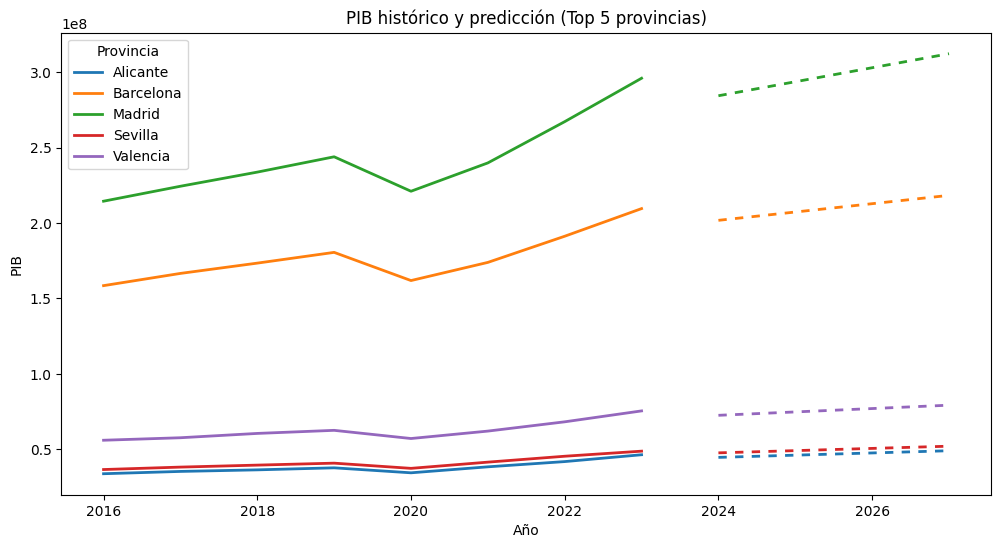

In [36]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_plot[df_plot["Tipo"] == "Real"],
    x="Año",
    y="Valor",
    hue="Provincia",
    linewidth=2
)

sns.lineplot(
    data=df_plot[df_plot["Tipo"] == "Predicción"],
    x="Año",
    y="Valor",
    hue="Provincia",
    linestyle=(0, (3, 3)),  # guiones cortos repetidos
    linewidth=2,
    legend=False
)


plt.title("PIB histórico y predicción (Top 5 provincias)")
plt.xlabel("Año")
plt.ylabel("PIB")

plt.show()

In [37]:
df_plot

,Provincia,Año,Valor,Tipo
1,Alicante,2016,3.389908e+07,Real
6,Barcelona,2016,1.585162e+08,Real
31,Madrid,2016,2.144691e+08,Real
42,Sevilla,2016,3.667489e+07,Real
47,Valencia,2016,5.608330e+07,Real
53,Alicante,2017,3.542293e+07,Real
58,Barcelona,2017,1.666180e+08,Real
83,Madrid,2017,2.243732e+08,Real
94,Sevilla,2017,3.829066e+07,Real
99,Valencia,2017,5.773774e+07,Real


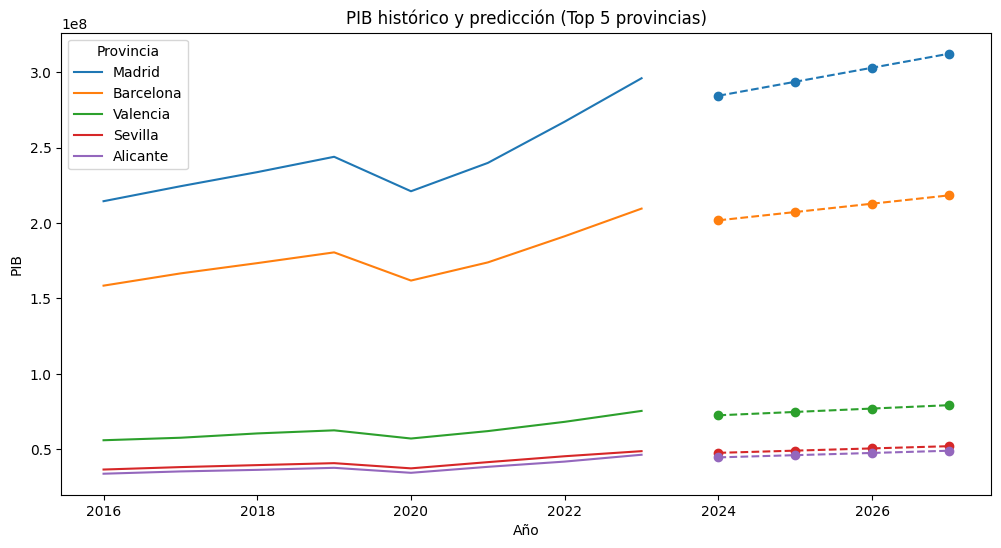

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))

for provincia in top5:
    datos_hist = df_plot[df_plot["Provincia"] == provincia].sort_values("Año")
    linea, = ax.plot(
        datos_hist.loc[datos_hist['Tipo']!='Predicción' ,"Año"],
        datos_hist.loc[datos_hist['Tipo']!='Predicción' ,"Valor"],
        label=provincia
    )

    color = linea.get_color()

    ultimo_hist = datos_hist.tail(1)
    datos_pred = df_pred[df_pred["Provincia"] == provincia].sort_values("Año")
    datos_linea_pred = pd.concat([ultimo_hist, datos_pred])

    ax.plot(
        datos_hist.loc[datos_hist['Tipo']=='Predicción' ,"Año"],
        datos_hist.loc[datos_hist['Tipo']=='Predicción' ,"Valor"],
        linestyle="--",
        marker="o",
        color=color
    )

ax.set_title("PIB histórico y predicción (Top 5 provincias)")
ax.set_xlabel("Año")
ax.set_ylabel("PIB")
ax.legend(title="Provincia")
plt.show()

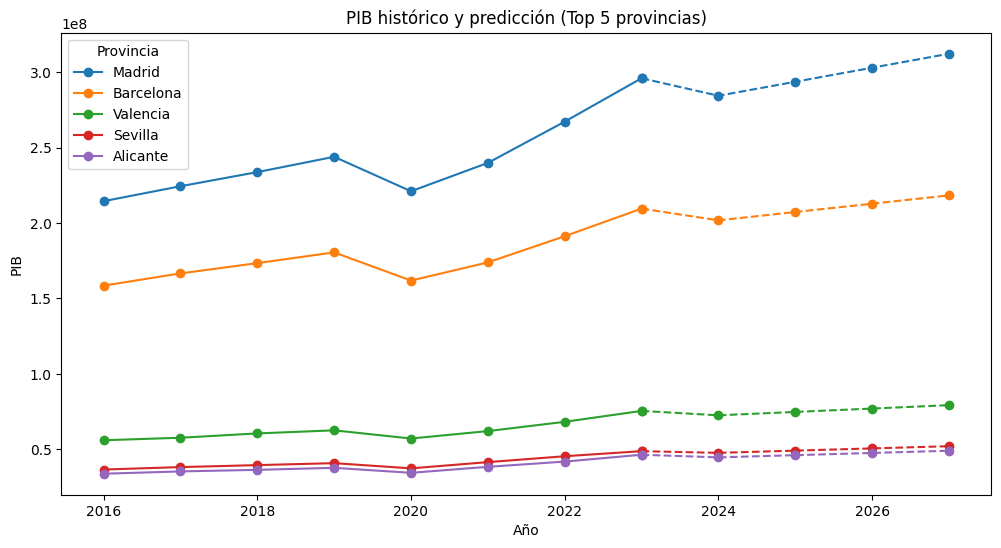

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(12, 6))

for provincia in top5:
    datos_prov = df_plot[df_plot["Provincia"] == provincia].sort_values("Año")

    datos_real = datos_prov[datos_prov["Tipo"] == "Real"]
    datos_pred = datos_prov[datos_prov["Tipo"] == "Predicción"]

    # Línea continua: valores reales
    linea_real, = ax.plot(
        datos_real["Año"],
        datos_real["Valor"],
        linestyle="-",
        marker="o",
        label=provincia
    )

    color = linea_real.get_color()

    # Unimos el último dato real con los datos predichos
    if not datos_real.empty and not datos_pred.empty:
        datos_pred_con_inicio = pd.concat([
            datos_real.tail(1),
            datos_pred
        ])

        ax.plot(
            datos_pred_con_inicio["Año"],
            datos_pred_con_inicio["Valor"],
            linestyle="--",
            marker="o",
            color=color
        )

ax.set_title("PIB histórico y predicción (Top 5 provincias)")
ax.set_xlabel("Año")
ax.set_ylabel("PIB")
ax.legend(title="Provincia")
plt.show()